In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn networkx

In [2]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [3]:
data = {
    "course_id": [1,2,3,4,5,6],
    "title": [
        "Python for Beginners",
        "Advanced Python Projects",
        "Web Development with React",
        "Full Stack MERN Development",
        "Data Science with Python",
        "Machine Learning Basics"
    ],
    "tags": [
        "python basics coding",
        "python advanced projects oop",
        "react javascript frontend",
        "mongodb express react node backend",
        "data science pandas numpy",
        "machine learning ai models"
    ]
}

df = pd.DataFrame(data)
df

,course_id,title,tags
0,1,Python for Beginners,python basics coding
1,2,Advanced Python Projects,python advanced projects oop
2,3,Web Development with React,react javascript frontend
3,4,Full Stack MERN Development,mongodb express react node backend
4,5,Data Science with Python,data science pandas numpy
5,6,Machine Learning Basics,machine learning ai models


In [4]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df["tags"])

cosine_sim = cosine_similarity(tfidf_matrix)
cosine_sim

array([[1.        , 0.21464157, 0.        , 0.        , 0.        ,
        0.        ],
       [0.21464157, 1.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , 0.19029138, 0.        ,
        0.        ],
       [0.        , 0.        , 0.19029138, 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        1.        ]])

In [5]:
def recommend(course_index, top_n=3):
    scores = list(enumerate(cosine_sim[course_index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    top_courses = scores[1:top_n+1]

    recommended = []
    for i in top_courses:
        recommended.append(df.iloc[i[0]]["title"])

    return recommended

In [6]:
print("Base Course:", df.iloc[0]["title"])
print("Recommended Courses:")
print(recommend(0))

Base Course: Python for Beginners
Recommended Courses:
['Advanced Python Projects', 'Web Development with React', 'Full Stack MERN Development']


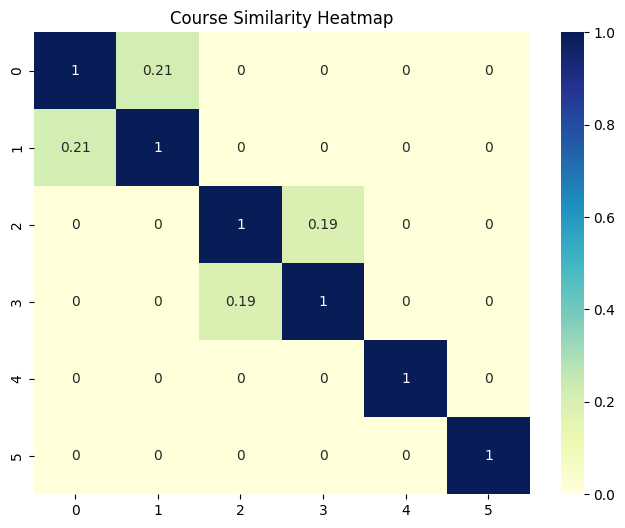

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(cosine_sim, annot=True, cmap="YlGnBu")
plt.title("Course Similarity Heatmap")
plt.show()

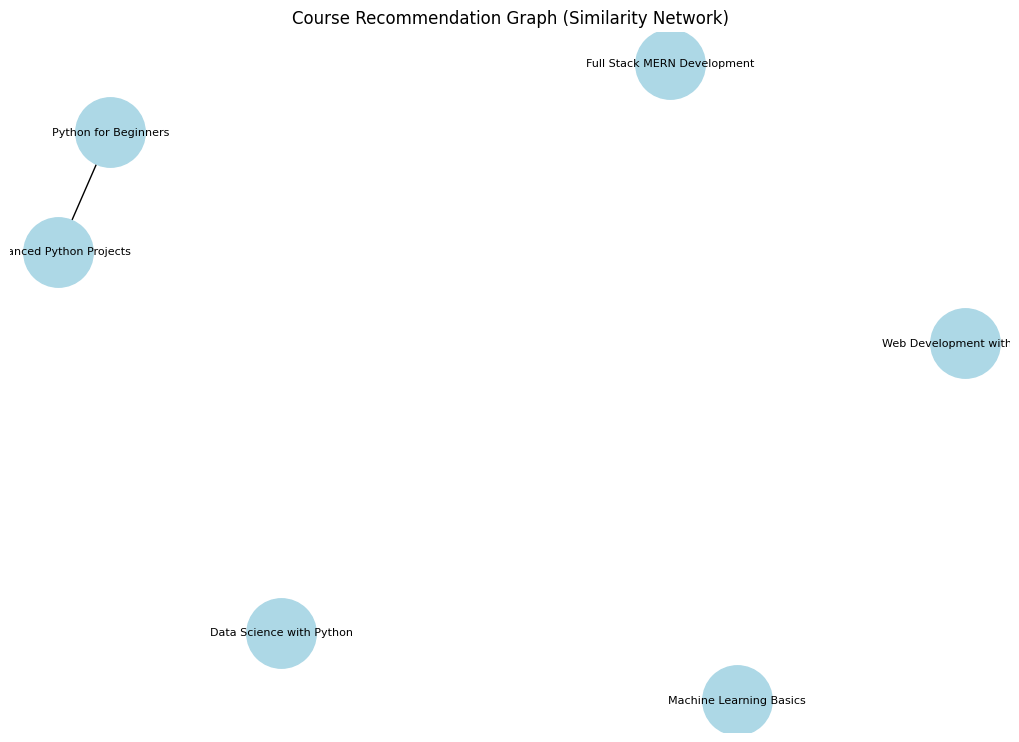

In [8]:
G = nx.Graph()

# Add nodes
for i in range(len(df)):
    G.add_node(df["title"][i])

# Add edges (similarity > 0.2)
for i in range(len(df)):
    for j in range(len(df)):
        if cosine_sim[i][j] > 0.2 and i != j:
            G.add_edge(df["title"][i], df["title"][j], weight=cosine_sim[i][j])

plt.figure(figsize=(10,7))
pos = nx.spring_layout(G, k=0.5)

nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=2500, font_size=8)
plt.title("Course Recommendation Graph (Similarity Network)")
plt.show()

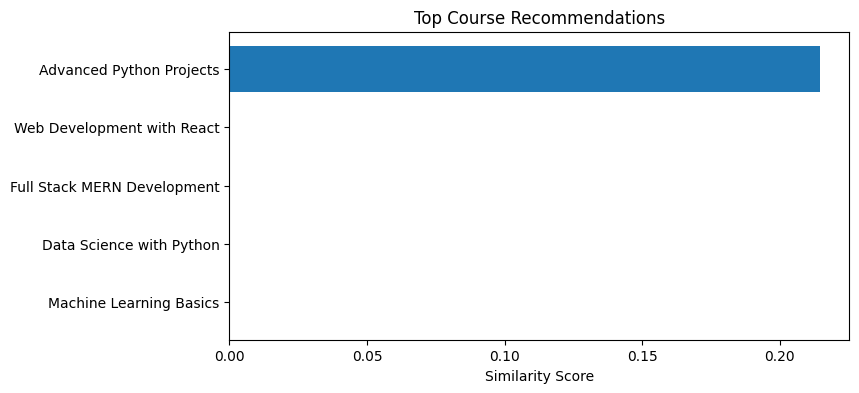

In [9]:
def plot_recommendations(course_index):
    scores = list(enumerate(cosine_sim[course_index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]

    names = [df.iloc[i[0]]["title"] for i in scores]
    values = [i[1] for i in scores]

    plt.figure(figsize=(8,4))
    plt.barh(names, values)
    plt.xlabel("Similarity Score")
    plt.title("Top Course Recommendations")
    plt.gca().invert_yaxis()
    plt.show()

plot_recommendations(0)